In [5]:
import numpy as np
import xarray as xr
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:


# Load CLaMS 2000 (overlaps with your AIDE rollout end)
clams = nc.Dataset('/data/CLaMS/CLaMS_v3/clams_reanalyses/clams_era5_zm_lat_press/clams_era5_zm_lat_press_2000.nc', mode='r')
print(clams.variables.keys())
print(clams.variables['BA'])

dict_keys(['lat', 'press', 'month', 'GPH', 'TEMP', 'THETA', 'H2O_rea', 'U', 'V', 'THETA_DOT_TOT', 'TROP1_PRESS', 'TROP1_THETA', 'H2O', 'BA', 'CV', 'N2O', 'CH4', 'F11', 'F12', 'CO', 'CO2'])
<class 'netCDF4.Variable'>
float32 BA(month, press, lat)
    long_name: Mean age clock tracer mixing ratio
    units: yr
    FLAG: NONE
    valid_min: 0.0
    valid_max: 5.553785
unlimited dimensions: 
current shape = (12, 38, 181)
filling on, default _FillValue of 9.969209968386869e+36 used


## CESM

In [7]:
BASE = ('/data/cesm2.1.5_output/histSST/'
        'f.e21.FWHIST.f09_f09_mg17.atmos-scale_fixedSST_1996-2014.001/'
        'archive/atm/proc/tseries/day_1/')

save_dir = '/home/ubuntu/noah/1997_2000_daily_means_cesm/'


co2_cesm = nc.Dataset(BASE + 'f.e21.FWHIST.f09_f09_mg17.atmos-scale_fixedSST_1996-2014.001.cam.h7.CO2.19960101-20141231.nc', mode='r')

co2_cesm['CO2']
#co2_cesm['lev'][49]
#co2_cesm['lat'][96-22]

<class 'netCDF4.Variable'>
float32 CO2(time, lev, lat, lon)
    mdims: 1
    units: mol/mol
    mixing_ratio: dry
    long_name: CO2 concentration
    cell_methods: time: mean
unlimited dimensions: time
current shape = (6936, 70, 192, 288)
filling on, default _FillValue of 9.969209968386869e+36 used

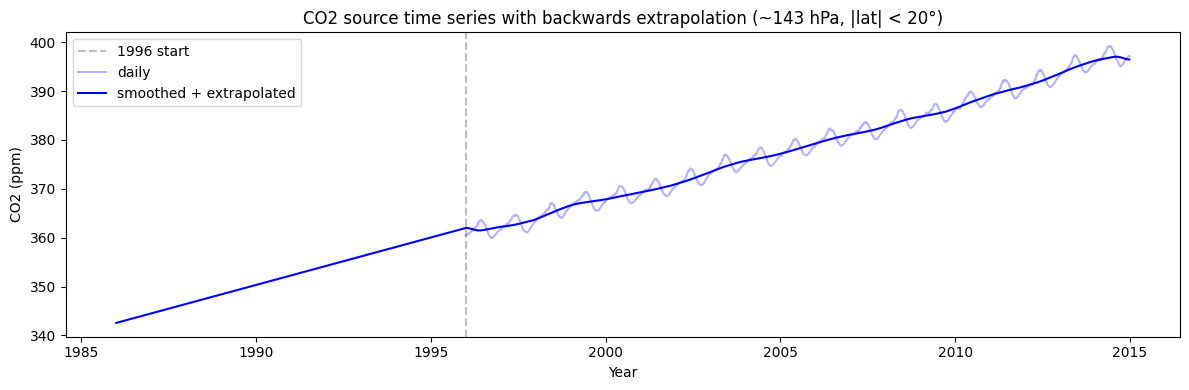

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

save_dir = '/home/ubuntu/noah/1997_2000_daily_means_cesm/'

CO2_zm = np.load(f"{save_dir}/CO2_zm_tropopause_1996_2014.npy")
CO2_source_ppm = CO2_zm.mean(axis=1) * 1e6  # (6935,)

# Smooth
CO2_smooth = uniform_filter1d(CO2_source_ppm, size=365)

# Fit linear trend to smoothed series
days = np.arange(len(CO2_smooth))
coeffs = np.polyfit(days, CO2_smooth, deg=1)

# Extrapolate backwards anchored to first smoothed value
n_back = 3650
days_back = np.arange(-n_back, 0)
CO2_back = CO2_smooth[0] + coeffs[0] * days_back

# Concatenate
CO2_extrap = np.concatenate([CO2_back, CO2_smooth])
days_extrap = np.arange(-n_back, len(CO2_smooth))

# Convert day index to year (0 = Jan 1 1996)
years_extrap = 1996 + days_extrap / 365.25

plt.figure(figsize=(12, 4))
plt.axvline(x=1996, color='gray', linestyle='--', alpha=0.5, label='1996 start')
plt.plot(1996 + days / 365.25, CO2_source_ppm, alpha=0.3, color='blue', label='daily')
plt.plot(years_extrap, CO2_extrap, 'b-', label='smoothed + extrapolated')
plt.ylabel('CO2 (ppm)')
plt.xlabel('Year')
plt.title('CO2 source time series with backwards extrapolation (~143 hPa, |lat| < 20°)')
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
save_dir = '/home/ubuntu/noah/1997_2000_daily_means_cesm/'

CO2_local = np.load(f"{save_dir}/CO2_zm_stratosphere_1996_2014.npy")

CO2_local

array([[[2.4065404e-05, 2.4081795e-05, 2.4090301e-05, ...,
         2.9771452e-05, 2.9588622e-05, 2.9483823e-05],
        [3.2293756e-05, 3.2323202e-05, 3.2404638e-05, ...,
         3.9754537e-05, 3.9665254e-05, 3.9574512e-05],
        [3.9974668e-05, 3.9967166e-05, 3.9956780e-05, ...,
         5.2942985e-05, 5.3133943e-05, 5.2828491e-05],
        ...,
        [3.5563318e-04, 3.5558644e-04, 3.5545955e-04, ...,
         3.5695467e-04, 3.5675845e-04, 3.5642809e-04],
        [3.5595821e-04, 3.5594165e-04, 3.5577713e-04, ...,
         3.5715103e-04, 3.5711925e-04, 3.5702024e-04],
        [3.5614037e-04, 3.5613714e-04, 3.5610329e-04, ...,
         3.5759018e-04, 3.5738884e-04, 3.5731989e-04]],

       [[2.0878158e-05, 2.0892030e-05, 2.0911963e-05, ...,
         3.3012784e-05, 3.2856435e-05, 3.2765322e-05],
        [2.7483928e-05, 2.7488746e-05, 2.7517435e-05, ...,
         4.2960761e-05, 4.2758602e-05, 4.2672971e-05],
        [3.5522244e-05, 3.5529181e-05, 3.5559766e-05, ...,
         5.626

In [10]:
print(f"Shape: {CO2_local.shape}")
print(f"Min: {CO2_local.min()*1e6:.2f} ppm")
print(f"Max: {CO2_local.max()*1e6:.2f} ppm")
print(f"Mean: {CO2_local.mean()*1e6:.2f} ppm")

Shape: (6935, 50, 192)
Min: 7.22 ppm
Max: 399.53 ppm
Mean: 319.67 ppm


In [11]:
from scipy.interpolate import interp1d
import numpy as np



f_inv = interp1d(CO2_extrap, days_extrap, bounds_error=False, fill_value=np.nan)

# Convert stratospheric CO2 to ppm from mol CO2 per mol air
CO2_local_ppm = CO2_local * 1e6  # (6935, 50, 192)


SKIP_DAYS = 365 * 8  # first 8 years without CLaMS output
CO2_local_ppm = CO2_local_ppm[SKIP_DAYS:]

age_days = np.zeros_like(CO2_local_ppm)

for i in range(len(CO2_local_ppm)):
    abs_day = i + SKIP_DAYS          # actual position in the original timeline
    day_entered = f_inv(CO2_local_ppm[i])
    age_days[i] = abs_day - day_entered   # both in the same day-number space         # age in days at this timestep

age_years = age_days / 365.25

# Mask unreasonable values
age_years[age_years < 0]  = np.nan
age_years[age_years > 15] = np.nan

# Climatological mean age
age_mean = np.nanmean(age_years, axis=0)  # (50, 192)

print(f"Age range: {np.nanmin(age_mean):.2f} to {np.nanmax(age_mean):.2f} years")



Age range: 0.46 to 15.00 years


/tmp/ipykernel_4118936/524417261.py:29: RuntimeWarning: Mean of empty slice
  age_mean = np.nanmean(age_years, axis=0)  # (50, 192)


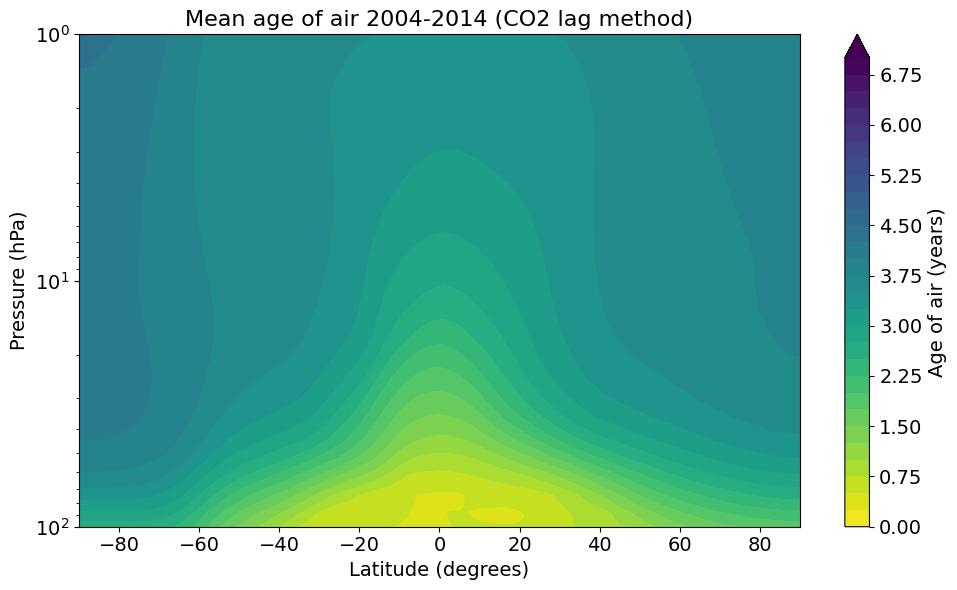

In [12]:
import matplotlib.pyplot as plt
import netCDF4 as nc

# Load pressure and lat info
ds = nc.Dataset(BASE + 'f.e21.FWHIST.f09_f09_mg17.atmos-scale_fixedSST_1996-2014.001.cam.h7.CO2.19960101-20141231.nc')
lev = np.array(ds['lev'][:50])   # hPa, top 50 levels
lat = np.array(ds['lat'][:])     # degrees

FONTSIZE = 14  # change this one number to scale everything

plt.figure(figsize=(10, 6))
cf = plt.contourf(lat, lev, age_mean,
                  levels=np.arange(0, 7.25, 0.25),
                  cmap='viridis_r',
                  extend='max')

cbar = plt.colorbar(cf, label='Age of air (years)')
cbar.set_label('Age of air (years)', fontsize=FONTSIZE)
cbar.ax.tick_params(labelsize=FONTSIZE)

plt.yscale('log')
plt.gca().invert_yaxis()
plt.ylim([100, 1])
plt.xlabel('Latitude (degrees)', fontsize=FONTSIZE)
plt.ylabel('Pressure (hPa)', fontsize=FONTSIZE)
plt.title('Mean age of air 2004-2014 (CO2 lag method)', fontsize=FONTSIZE + 2)
plt.xticks(fontsize=FONTSIZE)
plt.yticks(fontsize=FONTSIZE)
plt.tight_layout()
plt.show()

## Various AoA techniques using the lag method

In [13]:
import numpy as np
import pandas as pd
import sys
save_dir = '/home/ubuntu/noah/1997_2000_daily_means_cesm/'
home_dir = '/home/ubuntu/noah/'

sys.path.append(f'{home_dir}/AtmosphericAngels-AoA_from_convolution-106270e')

from convolution_method_functions import Conc2Age_Convolution
print("Import successful")



# --- Load Ray et al. reference ---
CO2_ref = pd.read_csv(
    f'{home_dir}/AtmosphericAngels-AoA_from_convolution-106270e/tropical_time_series/CO2_tropical_surface_time_series_Ray.txt',
    delim_whitespace=True, header=5, names=['time', 'vmr']
)
CO2_ref_t   = np.array(CO2_ref['time'])
CO2_ref_vmr = np.array(CO2_ref['vmr'])

# --- Load CESM reference (tropopause time series) ---
CO2_zm      = np.load(f"{save_dir}/CO2_zm_tropopause_1996_2014.npy")  # (6935, 44)
CO2_cesm_vmr = CO2_zm.mean(axis=1) * 1e6  # ppm, (6935,)

# CESM time axis in fractional years (daily, starting Jan 1 1996)
CO2_cesm_t = 1996 + np.arange(len(CO2_cesm_vmr)) / 365.25

# --- Load CESM stratospheric CO2 ---
CO2_strat = np.load(f"{save_dir}/CO2_zm_stratosphere_1996_2014.npy")  # (6935, 50, 192)
CO2_strat_ppm = CO2_strat * 1e6  # ppm

# --- Parameters ---
rom    = 1.2   # ratio of moments — standard starting value
t_obs  = 2005.0  # middle of 1996-2014 period as reference observation time

# --- Time-mean stratospheric CO2 ---
CO2_strat_mean = CO2_strat_ppm.mean(axis=0)  # (50, 192)

print(f"Strat CO2 range: {CO2_strat_mean.min():.2f} to {CO2_strat_mean.max():.2f} ppm")
print(f"Ray ref range:   {CO2_ref_vmr.min():.2f} to {CO2_ref_vmr.max():.2f} ppm")
print(f"CESM ref range:  {CO2_cesm_vmr.min():.2f} to {CO2_cesm_vmr.max():.2f} ppm")

Import successful
Strat CO2 range: 28.70 to 378.51 ppm
Ray ref range:   305.52 to 420.61 ppm
CESM ref range:  359.92 to 399.20 ppm


/tmp/ipykernel_4118936/176976900.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  CO2_ref = pd.read_csv(


In [14]:
import numpy as np
from convolution_method_functions import Conc2Age_Convolution

rom   = 1.2
t_obs = 2005.0

nlev, nlat = CO2_strat_mean.shape  # (50, 192)

age_ray  = np.full((nlev, nlat), np.nan)
age_cesm = np.full((nlev, nlat), np.nan)

print("Running convolution...", flush=True)
for k in range(nlev):
    if k % 5 == 0:
        print(f"  level {k}/{nlev}", flush=True)
    
    # Pass entire latitude array at once
    # Calling this once using the mean conc for the time period and the mean time. This isn't perfect but CO2 monotonically increases. Furthermore, calling each timestep would take hours to run.
    # using the ray CO2 ref and timestamps
    age_ray[k, :]  = Conc2Age_Convolution(
        t_ref=CO2_ref_t, c_ref=CO2_ref_vmr,
        t_obs=t_obs, c_obs=CO2_strat_mean[k, :], rom=rom
    )
    #using the cesm CO2 ref and timestamps
    age_cesm[k, :] = Conc2Age_Convolution(
        t_ref=CO2_cesm_t, c_ref=CO2_cesm_vmr,
        t_obs=t_obs, c_obs=CO2_strat_mean[k, :], rom=rom
    )

print("Done")
print(f"Ray  age range: {np.nanmin(age_ray):.2f} to {np.nanmax(age_ray):.2f} years")
print(f"CESM age range: {np.nanmin(age_cesm):.2f} to {np.nanmax(age_cesm):.2f} years")



Running convolution...
  level 0/50
  level 5/50
  level 10/50
  level 15/50
  level 20/50
  level 25/50
  level 30/50
  level 35/50
  level 40/50
  level 45/50
Done
Ray  age range: 1.00 to 10.00 years
CESM age range: 1.00 to 9.96 years


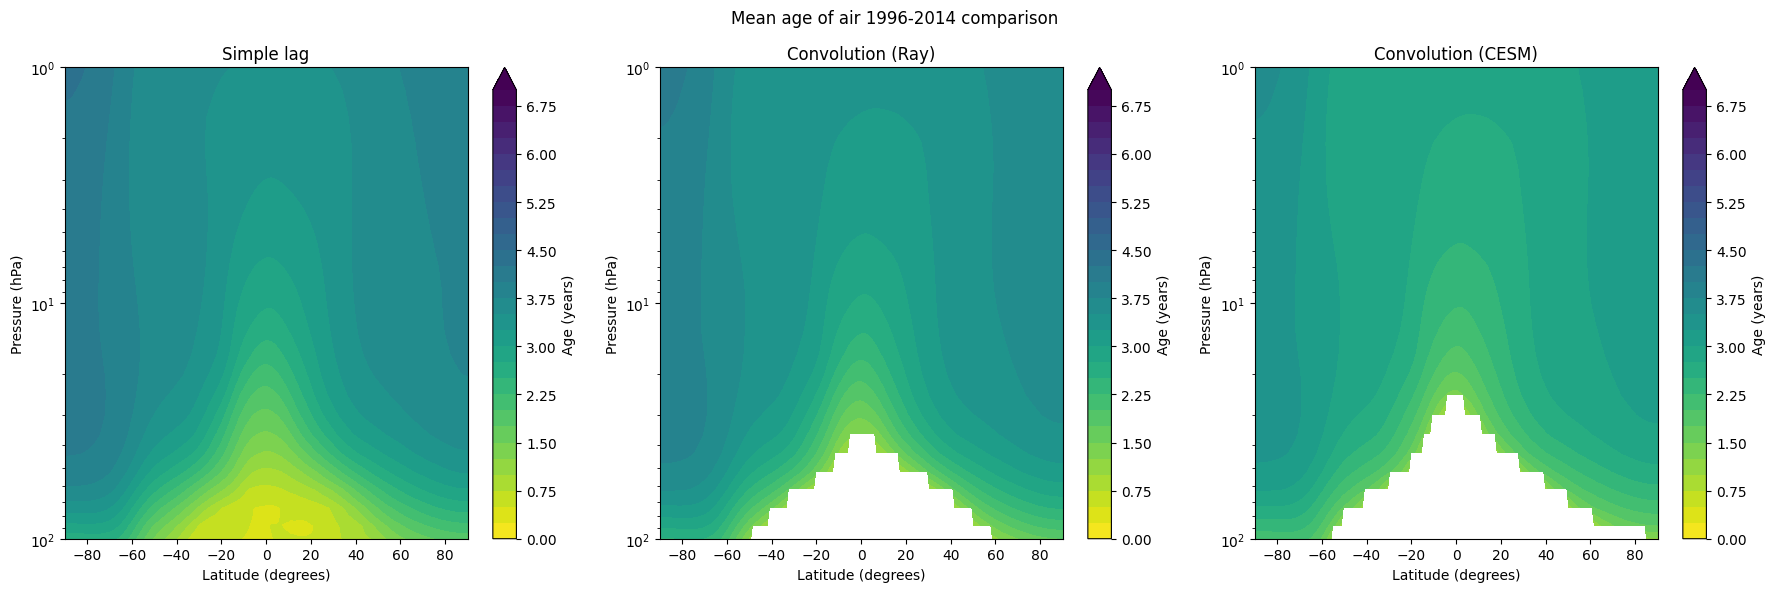

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
levels = np.arange(0, 7.25, 0.25)

for ax, age, title in zip(axes,
                           [age_mean, age_ray, age_cesm],
                           ['Simple lag', 'Convolution (Ray)', 'Convolution (CESM)']):
    cf = ax.contourf(lat, lev, age, levels=levels, cmap='viridis_r', extend='max')
    plt.colorbar(cf, ax=ax, label='Age (years)')
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_ylim([100,1])
    ax.set_xlabel('Latitude (degrees)')
    ax.set_ylabel('Pressure (hPa)')
    ax.set_title(title)

plt.suptitle('Mean age of air 1996-2014 comparison')
plt.tight_layout()
plt.show()

## H2O (can't do this because it isn't monotonic)

In [16]:
BASE = ('/data/cesm2.1.5_output/histSST/'
        'f.e21.FWHIST.f09_f09_mg17.atmos-scale_fixedSST_1996-2014.001/'
        'archive/atm/proc/tseries/month_1/')

h2o_cesm = nc.Dataset(BASE + 'f.e21.FWHIST.f09_f09_mg17.atmos-scale_fixedSST_1996-2014.001.cam.h0.H2O.199601-201412.nc', mode='r')

h2o_cesm['H2O']

<class 'netCDF4.Variable'>
float32 H2O(time, lev, lat, lon)
    mdims: 1
    units: mol/mol
    long_name: water vapor concentration
    cell_methods: time: mean
unlimited dimensions: time
current shape = (228, 70, 192, 288)
filling on, default _FillValue of 9.969209968386869e+36 used

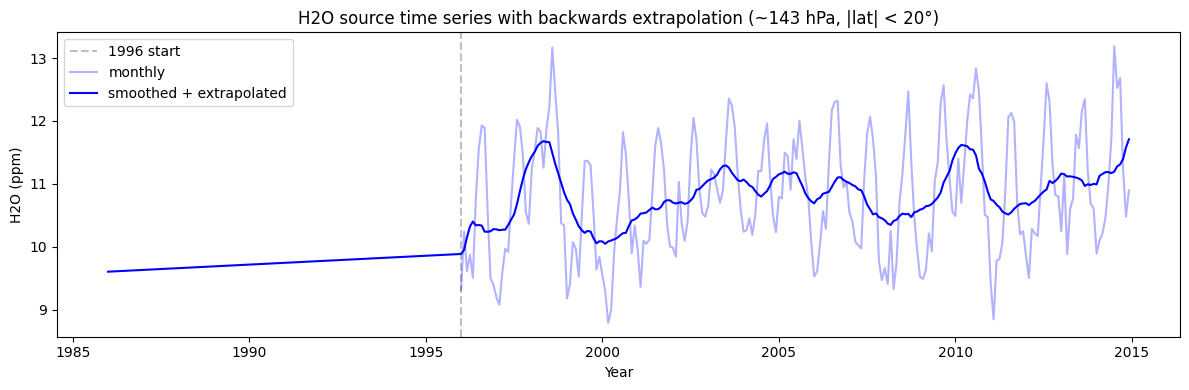

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

save_dir = '/home/ubuntu/noah/1997_2000_daily_means_cesm/'

H2O_zm = np.load(f"{save_dir}/H2O_zm_tropopause_1996_2014.npy")
H2O_source_ppm = H2O_zm.mean(axis=1) * 1e6  # (228,) — monthly means

# Smooth
H2O_smooth = uniform_filter1d(H2O_source_ppm, size=12)  # 12-month window instead of 365-day

# Fit linear trend to smoothed series
months = np.arange(len(H2O_smooth))
coeffs = np.polyfit(months, H2O_smooth, deg=1)

# Extrapolate backwards anchored to first smoothed value
n_back = 120  # 10 years back in months instead of 3650 days
months_back = np.arange(-n_back, 0)
H2O_back = H2O_smooth[0] + coeffs[0] * months_back

# Concatenate
H2O_extrap = np.concatenate([H2O_back, H2O_smooth])
months_extrap = np.arange(-n_back, len(H2O_smooth))

# Convert month index to year (0 = Jan 1 1996)
years_extrap = 1996 + months_extrap / 12

plt.figure(figsize=(12, 4))
plt.axvline(x=1996, color='gray', linestyle='--', alpha=0.5, label='1996 start')
plt.plot(1996 + months / 12, H2O_source_ppm, alpha=0.3, color='blue', label='monthly')
plt.plot(years_extrap, H2O_extrap, 'b-', label='smoothed + extrapolated')
plt.ylabel('H2O (ppm)')
plt.xlabel('Year')
plt.title('H2O source time series with backwards extrapolation (~143 hPa, |lat| < 20°)')
plt.legend()
plt.tight_layout()
plt.show()

## From residual velocities

In [18]:
"""
Compute Mean Age of Air from TEM residual circulation + diffusion
=================================================================
Solves the steady-state transport equation (Neu & Plumb 1999, eq. 2):
 
    v* dΓ/dy + w* dΓ/dz - D_yy d²Γ/dy² = 1
 
where v*, w* are the residual mean velocities from https://angeo.copernicus.org/articles/39/357/2021/ equations 3 and 4:
 
    v* = v - 1/(dθ/dz) * (-v'θ'/H + dv'θ'/dz - v'θ'/(dθ/dz) * d²θ/dz²)
    w* = w + 1/(a cosφ) * 1/(dθ/dz) * (-sinφ v'θ' + cosφ(dv'θ'/dφ - v'θ'/(dθ/dz) * d²θ/dzdφ))
Boundary condition: Γ = 0 at 100 hPa (tropical tropopause)
 
Inputs (all from h6 daily files, time-averaged):
    Vzm   : zonal-mean meridional wind (m/s)
    Wzm   : zonal-mean vertical wind (m/s) - geometric vertical velocity
    VTHzm : total meridional heat flux v*theta (MK/S = m K/s)
    THzm  : zonal-mean potential temperature (K)
 
Notes on units from metadata:
    - Wzm is m/s (geometric), NOT Pa/s (omega)
    - VTHzm is total flux — eddy component = VTHzm - Vzm*THzm
    - All h6 variables are on ilev (71 levels), not lev (70 levels)
 
Dependencies:
    pip install numpy scipy netCDF4 matplotlib
"""
 
import os
import numpy as np
import netCDF4 as nc
from scipy import sparse
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
 
# ── 0. Paths ───────────────────────────────────────────────────────────────────
BASE = ('/data/cesm2.1.5_output/histSST/'
        'f.e21.FWHIST.f09_f09_mg17.atmos-scale_fixedSST_1996-2014.001/'
        'archive/atm/proc/tseries/day_1/')
 
def load_h6(var):
    fname = [f for f in os.listdir(BASE) if f'h6.{var}.' in f][0]
    ds = nc.Dataset(os.path.join(BASE, fname))
    raw  = ds.variables[var][:]
    ilev = ds.variables['ilev'][:]
    lat  = ds.variables['lat'][:]
    ds.close()

    data = np.array(raw, dtype=float)
    data[np.abs(data) > 1e30] = np.nan
    return np.squeeze(np.nanmean(data, axis=0)), ilev, lat
 
# ── 1. Load all variables ──────────────────────────────────────────────────────
print("Loading h6 variables...")
v_bar,   ilev, lat = load_h6('Vzm')     # Eulerian v_bar  (ilev, lat)  m/s
print("check")
w_bar,   _,    _   = load_h6('Wzm')     # Eulerian w_bar  (ilev, lat)  m/s 
vth_tot, _,    _   = load_h6('VTHzm')   # total v*theta   (ilev, lat)  m K/s
th_bar,  _,    _   = load_h6('THzm')    # theta_bar       (ilev, lat)  K
 
print(f"Grid: {len(ilev)} levels, {len(lat)} latitudes")
print(f"Pressure range: {ilev.min():.2e} - {ilev.max():.2f} hPa")
print(f"Latitude range: {lat.min():.1f} - {lat.max():.1f} degrees")

Loading h6 variables...


/tmp/ipykernel_4118936/4116937287.py:51: RuntimeWarning: Mean of empty slice
  return np.squeeze(np.nanmean(data, axis=0)), ilev, lat


check
Grid: 71 levels, 192 latitudes
Pressure range: 4.50e-06 - 1000.00 hPa
Latitude range: -90.0 - 90.0 degrees


In [19]:
r_earth = 6.371e6
lat_rad = np.deg2rad(lat)
cos_lat = np.cos(lat_rad)
sin_lat = np.sin(lat_rad)


# ── 1b. Mask to stratosphere (1-100 hPa) ──────────────────────────────────────
strat_mask = (ilev >= 1.0) & (ilev <= 100.0)
ilev    = ilev[strat_mask]
v_bar   = v_bar[strat_mask, :]
w_bar   = w_bar[strat_mask, :]
vth_tot = vth_tot[strat_mask, :]
th_bar  = th_bar[strat_mask, :]
print(f"\nAfter masking: {len(ilev)} levels from {ilev.min():.1f} to {ilev.max():.1f} hPa")
print(np.shape(th_bar))

# ── 2. Eddy heat flux — confirmed from CAM source code (ctem.F90) ─────────────
# VTHzm = v'θ' directly, no subtraction needed
vth_eddy = vth_tot  # (ilev, lat)  m K/s

print(f"v'θ' range: {vth_eddy.min():.4f} to {vth_eddy.max():.4f} m K/s")

# ── 3. Compute dθ/dz in log-pressure coordinates ──────────────────────────────
H   = 7000.0        # scale height m
p0  = 101325.0      # reference pressure Pa

p_pa = ilev * 100.0                              # hPa → Pa
z    = -H * np.log(p_pa / p0)                   # (ilev,) m

# ── Flip to bottom→top (increasing z) ────────────────────────────────────────
ilev    = ilev[::-1]
z       = z[::-1]
v_bar   = v_bar[::-1, :]
w_bar   = w_bar[::-1, :]
vth_tot = vth_tot[::-1, :]
th_bar  = th_bar[::-1, :]
vth_eddy = vth_tot

print("z", z)

th_bar_z    = np.gradient(th_bar,    z,       axis=0)
th_bar_zz   = np.gradient(th_bar_z,  z,       axis=0)
th_bar_zphi = np.gradient(th_bar_z,  lat_rad, axis=1)
dvth_dz     = np.gradient(vth_eddy,  z,       axis=0)
dvth_dphi   = np.gradient(vth_eddy,  lat_rad, axis=1)

print(f"dθ/dz range: {th_bar_z.min():.4f} to {th_bar_z.max():.4f} K/m  (expect positive)")

# ── 4. Residual velocities ────────────────────────────────────────────────────
th_bar_z_safe = np.where(np.abs(th_bar_z) > 0, th_bar_z, np.nan)

cos_lat_safe = np.where(np.abs(cos_lat) > 0.01, cos_lat, np.nan)

term1 = -vth_eddy / H
term2 =  dvth_dz
term3 = -vth_eddy / th_bar_z_safe * th_bar_zz

v_star = v_bar - (1.0 / th_bar_z_safe) * (term1 + term2 + term3)

termA = -sin_lat[np.newaxis, :] * vth_eddy
termB =  cos_lat[np.newaxis, :] * (dvth_dphi - vth_eddy / th_bar_z_safe * th_bar_zphi)

w_star = w_bar + (1.0 / (r_earth * cos_lat_safe[np.newaxis, :])) * \
         (1.0 / th_bar_z_safe) * (termA + termB)

# ── Continuity check (corrected form) ────────────────────────────────────────
rho    = np.exp(-z / H)[:, None]                               # (nz, 1)
cosphi = np.cos(lat_rad)[None, :]                              # (1, ny)

term_y = np.gradient(v_star * cosphi, r_earth * lat_rad, axis=1)
term_z = (1.0 / rho) * np.gradient(rho * w_star * cosphi, z, axis=0)
div    = np.nan_to_num(term_y + term_z)

scale  = np.nanmean(np.abs(term_z))
print(f"continuity residual (interior |lat|<60): "   ##want a value ~10%
      f"{np.nanmean(np.abs(div[:, np.abs(lat)<60])) / scale:.3f}")
print(f"continuity residual (polar   |lat|>60): "
      f"{np.nanmean(np.abs(div[:, np.abs(lat)>60])) / scale:.3f}")


print(f"Polar points masked: {np.isnan(w_star).sum()} of {w_star.size}")
print(f"v* range: {np.nanmin(v_star):.4f} to {np.nanmax(v_star):.4f} m/s")
print(f"v* mean:  {np.nanmean(v_star):.4f} m/s")
print(f"w* range: {np.nanmin(w_star):.2e} to {np.nanmax(w_star):.2e} m/s")
print(f"w* mean:  {np.nanmean(w_star):.2e} m/s")

print(f"w_bar mean: {np.nanmean(w_bar):.2e}")
print(f"w* correction mean: {np.nanmean(w_star - w_bar):.2e}")
print(f"w* tropics (|lat|<20) mean: {np.nanmean(w_star[:, np.abs(lat)<20]):.2e}")


After masking: 22 levels from 1.1 to 94.9 hPa
(22, 192)
v'θ' range: -379.6176 to 601.9767 m K/s
z [16573.635212836907 17711.134814778212 19034.45416462544 20238.96801505589
 21478.36235512014 22752.666816054516 24061.934598976917
 25406.099379128984 26785.148976947712 28199.062998638852
 29647.943157611673 31131.867624674338 32650.566338019937
 34204.08313845184 35792.59620509254 37416.05649581937 39074.39357641087
 40767.70126823021 42495.970002918264 44258.996616465956 46056.95599854631
 47889.963635792934]
dθ/dz range: 0.0155 to 0.0878 K/m  (expect positive)
continuity residual (interior |lat|<60): 0.112
continuity residual (polar   |lat|>60): 0.033
Polar points masked: 44 of 4224
v* range: -0.4906 to 0.4437 m/s
v* mean:  0.0058 m/s
w* range: -3.04e-03 to 8.84e-04 m/s
w* mean:  -2.56e-04 m/s
w_bar mean: 3.38e-04
w* correction mean: -5.67e-04
w* tropics (|lat|<20) mean: 4.36e-04


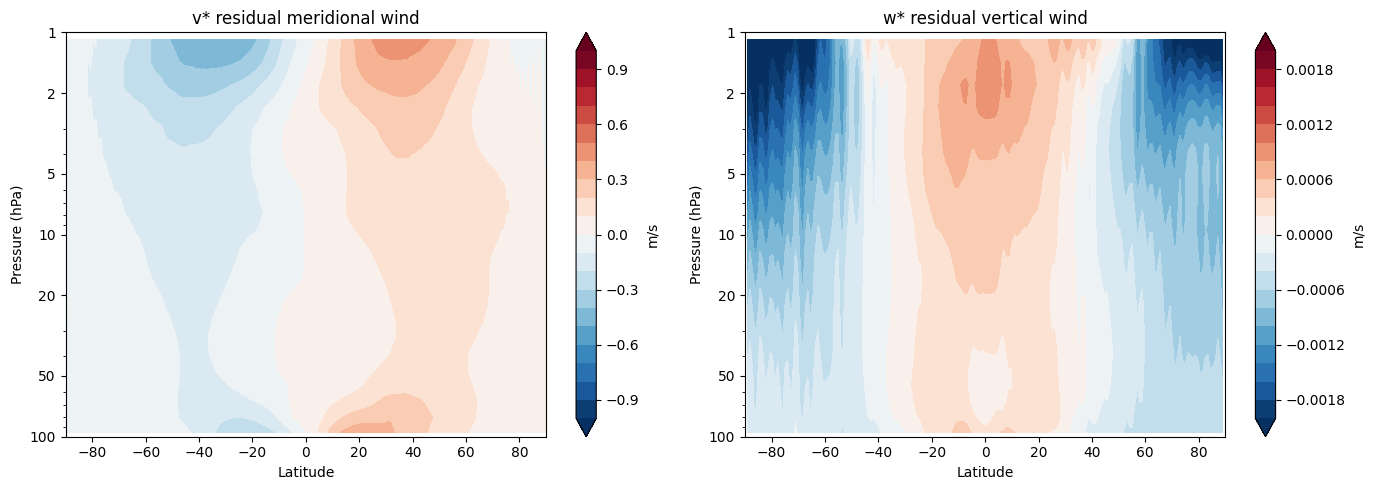

In [20]:
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cf1 = axes[0].contourf(lat, ilev, v_star, 
                        levels=np.linspace(-1, 1, 21), 
                        cmap='RdBu_r', extend='both')
plt.colorbar(cf1, ax=axes[0], label='m/s')
axes[0].set_yscale('log')
axes[0].invert_yaxis()
axes[0].set_title('v* residual meridional wind')
axes[0].set_xlabel('Latitude')
axes[0].set_ylabel('Pressure (hPa)')
axes[0].yaxis.set_major_formatter(mticker.ScalarFormatter())
axes[0].set_yticks([1, 2, 5, 10, 20, 50, 100])

cf2 = axes[1].contourf(lat, ilev, w_star, 
                        levels=np.linspace(-0.002, 0.002, 21), 
                        cmap='RdBu_r', extend='both')
plt.colorbar(cf2, ax=axes[1], label='m/s')
axes[1].set_yscale('log')
axes[1].invert_yaxis()
axes[1].set_title('w* residual vertical wind')
axes[1].set_xlabel('Latitude')
axes[1].set_ylabel('Pressure (hPa)')
axes[1].yaxis.set_major_formatter(mticker.ScalarFormatter())
axes[1].set_yticks([1, 2, 5, 10, 20, 50, 100])

plt.tight_layout()
plt.show()

## NOTE: K_yy IS VERY UNCERTAIN HERE AND NOT STRAIGHTFORWARD TO DERIVE!!

In [21]:
# ── 5. Solve steady-state age of air ──────────────────────────────────────────
# v* dΓ/dy + w* dΓ/dz - K_yy d²Γ/dy² = 1
#
# Discretized on 2D grid (nz, ny), solved as sparse linear system A*Gamma = b

K_yy = 2e5  # m2/s — mid-latitude surf zone estimate (not 1e6, that's tropospheric)


# ── K_yy: simple 3×3 anchor grid (pressure × latitude band) ───────────────────
# Pressure: low (100), mid (30), high (3) hPa
# Latitude: tropics (10°), midlat (50°), pole (80°)
# Values from Fig A1 / barrier-erosion extrapolation.
nz, ny = v_star.shape

p_anchor   = np.array([100.0, 30.0, 3.0])        # hPa: low, mid, high strat
lat_anchor = np.array([10.0, 22.0, 28.0, 50.0, 70.0])
K_anchor = np.array([
    [5e5, 5e5, 3e5, 1e6, 3e5],     # 100 hPa
    [5e3, 5e3, 2e5, 2e6, 4e5],     #  30 hPa  (deep floor, hard jump 22→28°)
    [1e5, 1e5, 3e5, 2e6, 6e5],     #   3 hPa
])

p_solver = (101325.0 * np.exp(-z / 7000.0)) / 100.0   # hPa, same orient as z
abslat   = np.abs(lat)
logK     = np.log10(K_anchor)

# interp in log-pressure (axis 0) onto solver levels, per lat band
logK_p = np.empty((nz, len(lat_anchor)))
for j in range(len(lat_anchor)):
    logK_p[:, j] = np.interp(np.log10(p_solver),
                             np.log10(p_anchor[::-1]), logK[::-1, j])

# interp in latitude onto solver lats
K_yy_2d = np.empty((nz, ny))
for iz in range(nz):
    K_yy_2d[iz, :] = 10.0 ** np.interp(abslat, lat_anchor, logK_p[iz, :])

K_yy_2d = np.maximum(K_yy_2d, 1e4)
print(f"K_yy_2d range: {K_yy_2d.min():.2e} to {K_yy_2d.max():.2e} m²/s")
print(f"tropics: {K_yy_2d[:, abslat<20].mean():.2e}  surf: {K_yy_2d[:, (abslat>30)&(abslat<60)].mean():.2e}")

dy = r_earth * np.gradient(lat_rad)          # (ny,)  m  converting into meters from coordinate spacing
dz_vec = np.gradient(z)                      # (nz,)  m  vertical spacing

nz, ny = v_star.shape 
print(v_star.shape) 
N = nz * ny


def idx(iz, iy):
    return iz * ny + iy   ##index*row(gets you to right row (vertical level))...iy gets you to the right column (latitude)

rows, cols, vals = [], [], []
b = np.ones(N)  # RHS = 1 (age of air source term)

for iz in range(nz):
    for iy in range(ny):
        k = idx(iz, iy)  ##get the current position in the flattened array

        trop_source_lat = 20.0   # degrees

        if iz == 0:

            # Tropical source region
            if abs(lat[iy]) <= trop_source_lat:

                # Gamma = 0
                rows.append(k)
                cols.append(k)
                vals.append(1.0)

                b[k] = 0.0

            else:

                # dGamma/dz = 0
                # Gamma(0,iy) - Gamma(1,iy) = 0

                rows += [k, k]
                cols += [k, idx(1, iy)]
                vals += [1.0, -1.0]

                b[k] = 0.0

            continue
   

        # ── Boundary condition: dΓ/dz = 0 at top (iz = nz-1) ──
        # Γiz​−Γ{iz−1​}=0 zero vertical gradient at the border
        if iz == nz - 1:
            rows.append(k); cols.append(k);         vals.append(1.0)
            rows.append(k); cols.append(idx(iz-1, iy)); vals.append(-1.0)
            b[k] = 0.0
            continue

        # ── Polar boundaries: dΓ/dy = 0 ──
        if iy == 0 or iy == ny - 1:
            rows.append(k); cols.append(k); vals.append(1.0)
            if iy == 0: #southern boundary (forward differencing...sign isn't important because we're setting the gradient to zero)
                rows.append(k); cols.append(idx(iz, iy+1)); vals.append(-1.0)
            else: #northern boundary (backward differencing)
                rows.append(k); cols.append(idx(iz, iy-1)); vals.append(-1.0)
            b[k] = 0.0
            continue

        dz = dz_vec[iz] # grab the local vertical spacing at this specific level (not constant)
        dy_c = dy[iy]   #grab the local horizontal spacing at this specific latitude (constant)

        ws = np.nan_to_num(w_star[iz, iy])
        vs = np.nan_to_num(v_star[iz, iy])

        # w* dΓ/dz — upwind differencing
        if ws >= 0:                  # flow going upward
            ###make sure to do += so terms can add!!!!!!!!!
            rows += [k,k]            # put value ws/dz   at matrix position (row=k,col=k)
            cols += [k, k-ny]  #put value -ws/dz  at matrix position (row=k, col=idx(iz-1,iy)) (full row before in idx, so right above in the matrix)
            vals += [ws/dz, -ws/dz]
        else:                       # flow going downward
            rows += [k, k]
            cols += [k, k+ny]
            vals += [-ws/dz, ws/dz]

        # v* dΓ/dy — upwind differencing
        if vs >= 0:                              # flow going northward
            rows += [k, k]
            cols += [k, k-1]          # use point to the south (upstream)
            vals += [vs/dy_c, -vs/dy_c]         # Γ_i * vs/dy - Γ_{i-1} * vs/dy

        else:                                    # flow going southward
            rows += [k, k]
            cols += [k, k+1]          # use point to the north (upstream)
            vals += [-vs/dy_c, vs/dy_c]         #Γ_{i+1} * vs/dy - Γ_{i} * vs/dy

        # -K_yy d²Γ/dy² — central differencing
        rows += [k, k, k]
        cols += [k-1, k, k+1]
        vals += [-K_yy_2d[iz, iy]/dy_c**2, 2*K_yy_2d[iz, iy]/dy_c**2, -K_yy_2d[iz, iy]/dy_c**2]



# ── Sanity checks before solving ──────────────────────────────────────────────

print("=== Grid ===")
print(f"z range: {z.min():.0f} to {z.max():.0f} m")
print(f"z[0]={z[0]:.0f}, z[-1]={z[-1]:.0f}  (should increase bottom→top)")
print(f"ilev[0]={ilev[0]:.1f}, ilev[-1]={ilev[-1]:.1f} hPa")

print("\n=== dθ/dz ===")
print(f"Should be positive everywhere in stratosphere")
print(f"Min: {th_bar_z.min():.4f}, Max: {th_bar_z.max():.4f} K/m")
print(f"Fraction negative: {(th_bar_z < 0).mean():.3f}")

print("\n=== Residual velocities ===")
print(f"v* mean: {np.nanmean(v_star):.6f} m/s  (expect ~0, small)")
print(f"w* mean: {np.nanmean(w_star):.2e} m/s  (expect positive ~1e-4 m/s)")
print(f"w* median: {np.nanmedian(w_star):.2e} m/s")

print("\n=== Courant-like ratios (stability check) ===")
dz_mean = np.abs(np.diff(z)).mean()
dy_mean = np.abs(r_earth * np.diff(lat_rad)).mean()
print(f"mean dz: {dz_mean:.0f} m")
print(f"mean dy: {dy_mean:.0f} m")
print(f"|w*| * dt_eff / dz ~ {np.nanmean(np.abs(w_star)) / dz_mean:.2e}  (should be < 1)")
print(f"|v*| * dt_eff / dy ~ {np.nanmean(np.abs(v_star)) / dy_mean:.2e}  (should be < 1)")
print(f"K_yy / dy² ~ {K_yy / dy_mean**2:.2e}")
print(f"|v*| / dy  ~ {np.nanmean(np.abs(v_star)) / dy_mean:.2e}")
print(f"Diffusion dominates advection: {K_yy / dy_mean**2 > np.nanmean(np.abs(v_star)) / dy_mean}")

A = sparse.csr_matrix((vals, (rows, cols)), shape=(N, N))
Gamma = spsolve(A, b)
Gamma = Gamma.reshape(nz, ny)

# Convert seconds to years
Gamma_years = Gamma / (365.25 * 24 * 3600)

print(f"Age of air range: {np.nanmin(Gamma_years):.2f} to {np.nanmax(Gamma_years):.2f} years")

K_yy_2d range: 1.00e+04 to 1.95e+06 m²/s
tropics: 7.37e+04  surf: 1.01e+06
(22, 192)
=== Grid ===
z range: 16574 to 47890 m
z[0]=16574, z[-1]=47890  (should increase bottom→top)
ilev[0]=94.9, ilev[-1]=1.1 hPa

=== dθ/dz ===
Should be positive everywhere in stratosphere
Min: 0.0155, Max: 0.0878 K/m
Fraction negative: 0.000

=== Residual velocities ===
v* mean: 0.005773 m/s  (expect ~0, small)
w* mean: -2.56e-04 m/s  (expect positive ~1e-4 m/s)
w* median: -- m/s

=== Courant-like ratios (stability check) ===
mean dz: 1491 m
mean dy: 104791 m
|w*| * dt_eff / dz ~ 3.55e-07  (should be < 1)
|v*| * dt_eff / dy ~ 1.06e-06  (should be < 1)
K_yy / dy² ~ 1.82e-05
|v*| / dy  ~ 1.06e-06
Diffusion dominates advection: True
Age of air range: 0.00 to 3.39 years


/home/ubuntu/.local/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/tmp/ipykernel_4118936/1519044215.py:156: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  print(f"w* median: {np.nanmedian(w_star):.2e} m/s")


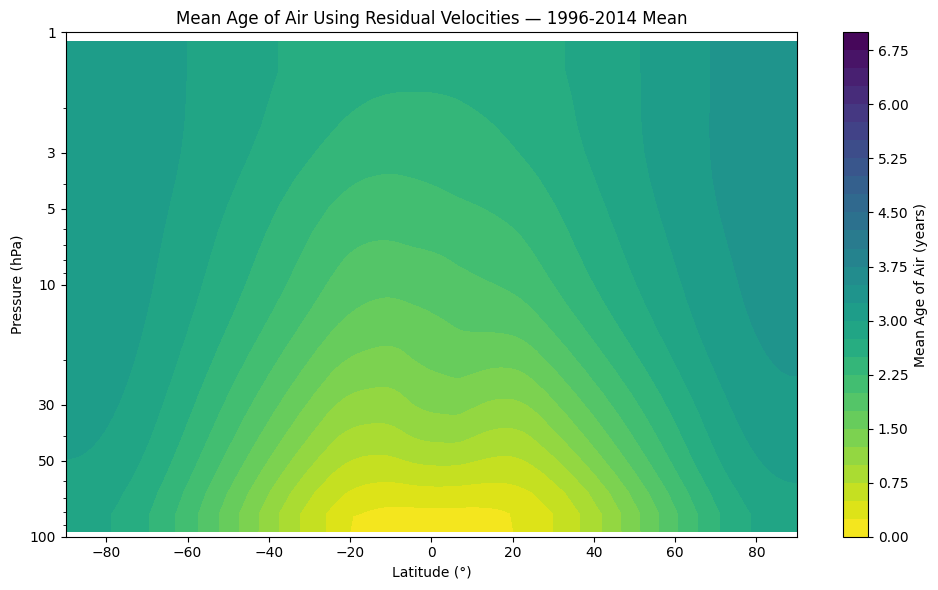

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
cf = ax.contourf(lat, ilev, Gamma_years,
                 levels=np.arange(0, 7.25, 0.25),
                 cmap='viridis_r')
plt.colorbar(cf, ax=ax, label='Mean Age of Air (years)')
ax.set_xlabel('Latitude (°)')
ax.set_ylabel('Pressure (hPa)')
ax.set_yscale('log')
ax.invert_yaxis()  # high pressure at bottom
ax.set_yticks([100, 50, 30, 10, 5, 3, 1])
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_title('Mean Age of Air Using Residual Velocities — 1996-2014 Mean')
plt.tight_layout()
plt.show()

## Using CESM direct output

In [2]:
import netCDF4 as nc
import numpy as np

BASE = ('/data/cesm2.1.5_output/histSST/'
        'f.e21.FWHIST.f09_f09_mg17.atmos-scale_fixedSST_1996-2014.001/'
        'archive/atm/proc/tseries/month_1/')

ds = nc.Dataset(BASE + 'f.e21.FWHIST.f09_f09_mg17.atmos-scale_fixedSST_1996-2014.001.cam.h0.AOA1.199601-201412.nc')

print(ds.variables['AOA1'])                      # units, long_name, shape
print("lev:", ds.variables['lev'][:])
aoa1 = ds.variables['AOA1'][:]
print("shape:", aoa1.shape)
print("range:", np.nanmin(aoa1), np.nanmax(aoa1))

ds = nc.Dataset(BASE + 'f.e21.FWHIST.f09_f09_mg17.atmos-scale_fixedSST_1996-2014.001.cam.h0.AOA2.199601-201412.nc')

print(ds.variables['AOA2'])                      # units, long_name, shape
print("lev:", ds.variables['lev'][:])
aoa2 = ds.variables['AOA2'][:]
print("shape:", aoa2.shape)
print("range:", np.nanmin(aoa2), np.nanmax(aoa2))

<class 'netCDF4.Variable'>
float32 AOA1(time, lev, lat, lon)
    mdims: 1
    units: kg/kg
    mixing_ratio: wet
    long_name: Age-of_air tracer 1
    cell_methods: time: mean
unlimited dimensions: time
current shape = (228, 70, 192, 288)
filling on, default _FillValue of 9.969209968386869e+36 used
lev: [5.96030003e-06 9.82690018e-06 1.62018505e-05 2.67122511e-05
 4.40410002e-05 7.26127478e-05 1.19719001e-04 1.97380004e-04
 3.25422505e-04 5.36532511e-04 8.84602485e-04 1.45845746e-03
 2.40457496e-03 3.97824988e-03 6.55682561e-03 1.08138256e-02
 1.78979999e-02 2.95577502e-02 4.87307498e-02 7.99107511e-02
 1.28273248e-01 1.98119997e-01 2.92025004e-01 4.10167500e-01
 5.53469989e-01 7.30479980e-01 9.55947500e-01 1.24479498e+00
 1.61285000e+00 2.07932497e+00 2.66742497e+00 3.40487505e+00
 4.32457495e+00 5.46539994e+00 6.87285000e+00 8.59972509e+00
 1.07070501e+01 1.32647501e+01 1.63517506e+01 2.00567506e+01
 2.44789999e+01 2.97279991e+01 3.59232500e+01 4.31937501e+01
 5.16774990e+01 6.15204

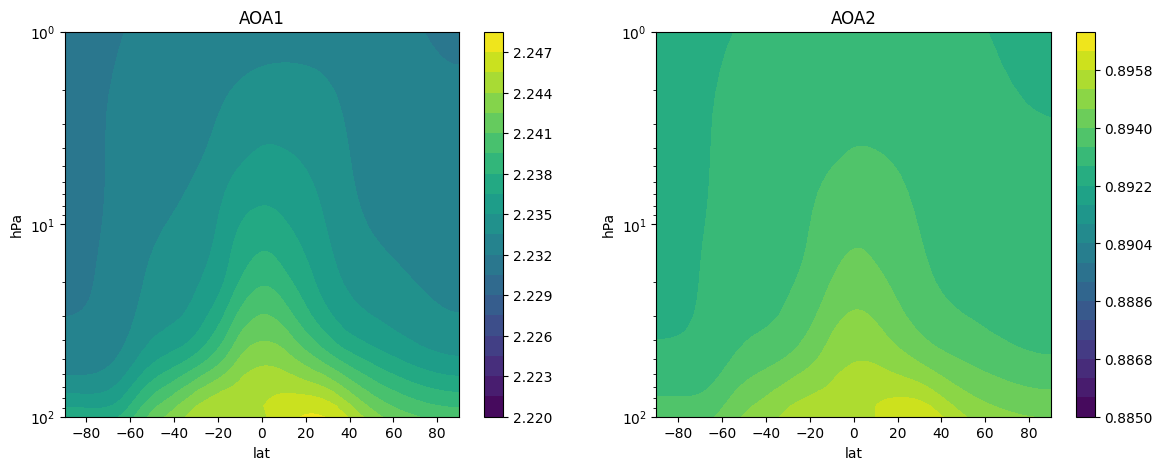

In [3]:
import matplotlib.pyplot as plt
lat = ds['lat'][:]
lev = ds['lev'][:]

aoa1_zm = aoa1.mean(axis=(0,3))   # (lev, lat)
aoa2_zm = aoa2.mean(axis=(0,3))

fig, ax = plt.subplots(1, 2, figsize=(14,5))
for a, fld, name in zip(ax, [aoa1_zm, aoa2_zm], ['AOA1','AOA2']):
    c = a.contourf(lat, lev, fld, levels=20, cmap='viridis')
    a.set_yscale('log'); a.invert_yaxis()
    a.set_ylim(100, 1)              # stratosphere
    a.set_title(name); a.set_xlabel('lat'); a.set_ylabel('hPa')
    fig.colorbar(c, ax=a)
plt.show()

AOA1: slope=0.00309/yr, total rise=0.05856, trend range=0.05842, noise std=0.00105
AOA2: slope=0.00061/yr, total rise=0.01161, trend range=0.01162, noise std=0.00052


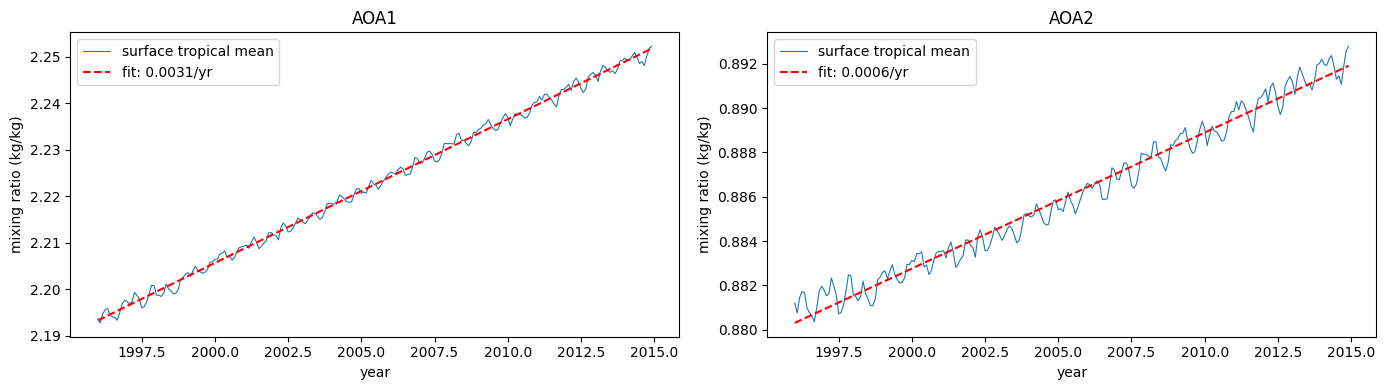

In [4]:
t_yr = np.arange(228) / 12.0

for name, arr in [('AOA1', aoa1), ('AOA2', aoa2)]:
    sfc = arr[:, -1, np.abs(ds['lat'][:]) < 20, :].mean(axis=(1,2))
    slope, intercept = np.polyfit(t_yr, sfc, 1)
    # how much of the total variation is the trend vs the wiggle?
    trend = slope * t_yr + intercept
    resid = sfc - trend
    print(f"{name}: slope={slope:.5f}/yr, total rise={sfc[-1]-sfc[0]:.5f}, "
          f"trend range={trend[-1]-trend[0]:.5f}, noise std={resid.std():.5f}")


lat = ds['lat'][:]
t_yr = 1996 + np.arange(228) / 12.0

sfc1 = aoa1[:, -1, np.abs(lat) < 20, :].mean(axis=(1,2))
sfc2 = aoa2[:, -1, np.abs(lat) < 20, :].mean(axis=(1,2))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

for a, sfc, name in zip(ax, [sfc1, sfc2], ['AOA1', 'AOA2']):
    s, i = np.polyfit(np.arange(228)/12.0, sfc, 1)
    a.plot(t_yr, sfc, lw=0.8, label='surface tropical mean')
    a.plot(t_yr, i + s*np.arange(228)/12.0, 'r--', label=f'fit: {s:.4f}/yr')
    a.set_title(name); a.set_xlabel('year'); a.set_ylabel('mixing ratio (kg/kg)')
    a.legend()

plt.tight_layout()
plt.show()